# Practica 5 - Sesion 1: Introduccion al Machine Learning con scikit-learn

## Ingeniería del Conocimiento    2025/2026
### Prof. Juan A. Recio García

En esta sesion vamos a recorrer el pipeline completo de un proyecto de machine learning desde cero. Utilizaremos el famoso dataset del Titanic para construir nuestro primer clasificador binario.

Existen numerosas librerías de ML: pytorch, tensor-flow, ... Nosotros utilizaremos scikit-learn ya que es la más apropiada para aprender ML. Écha un vistazo a la web: https://scikit-learn.org/stable/

---

## Contexto: el dataset del Titanic

El hundimiento del Titanic en 1912 es uno de los naufragios mas famosos de la historia. De los 2224 pasajeros y tripulantes, 1502 fallecieron. Disponemos de datos sobre los pasajeros (edad, sexo, clase del billete, etc.) y queremos predecir si un pasajero sobrevivio o no.

Este es un problema de **clasificacion binaria**: la variable objetivo (la que queremos predecir) solo puede tomar dos valores:
- `1` - el pasajero sobrevivio
- `0` - el pasajero no sobrevivio

## 1. Instalacion e importacion de librerias

Antes de empezar, nos aseguramos de tener instaladas las librerias necesarias. Ejecuta la siguiente celda solo si no las tienes instaladas.

In [ ]:
# Descomenta estas lineas si necesitas instalar las librerias
#!pip install pandas numpy scikit-learn matplotlib seaborn

In [1]:
# Librerias para manipulacion de datos
import pandas as pd
import numpy as np

# Librerias para visualizacion
import matplotlib.pyplot as plt
import seaborn as sns

# Librerias de scikit-learn que usaremos en esta sesion
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report, accuracy_score

print("Librerias importadas correctamente.")

Librerias importadas correctamente.


## 2. Carga del dataset

Vamos a descargar el dataset directamente desde la URL publica del repositorio de ejemplos de seaborn. Es el mismo dataset del Titanic que se usa en Kaggle, pero ya esta disponible sin necesidad de crear una cuenta.

La funcion `pd.read_csv()` de pandas nos permite leer un fichero CSV (valores separados por comas) y cargarlo en un **DataFrame**, que es la estructura de datos principal de pandas. Puedes pensar en un DataFrame como una tabla con filas y columnas.

In [2]:
# Cargamos el dataset directamente desde una URL publica
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)

print(f"Dataset cargado correctamente.")
print(f"Numero de filas (pasajeros): {df.shape[0]}")
print(f"Numero de columnas (variables): {df.shape[1]}")

Dataset cargado correctamente.
Numero de filas (pasajeros): 891
Numero de columnas (variables): 12


## 3. Exploracion inicial del dataset

Antes de entrenar cualquier modelo, siempre debemos explorar los datos para entender con que estamos trabajando. Esta fase se conoce como **EDA** (Exploratory Data Analysis).

Veamos las primeras filas del DataFrame:

In [3]:
# head() muestra las primeras 30 filas del DataFrame
df.head(30)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


Estas son las columnas del dataset y lo que representan:

| Columna | Descripcion |
|---|---|
| PassengerId | Identificador unico del pasajero |
| Survived | Variable objetivo: 1 = sobrevivio, 0 = no sobrevivio |
| Pclass | Clase del billete: 1 = primera, 2 = segunda, 3 = tercera |
| Name | Nombre del pasajero |
| Sex | Sexo del pasajero |
| Age | Edad del pasajero |
| SibSp | Numero de hermanos/conyuges a bordo |
| Parch | Numero de padres/hijos a bordo |
| Ticket | Numero de billete |
| Fare | Precio del billete |
| Cabin | Numero de cabina |
| Embarked | Puerto de embarque: C = Cherburgo, Q = Queenstown, S = Southampton |

> ### ¿Serías capaz de identificar a los supervivientes solo con esta información? ¿Qué variables te parecen más relevantes?
>
> Obviamente, para los humanos esta tarea es prácticamente imposible, pero gracias al ML podemos crear modelos que sí lo hagan con un porcentaje de acierto muy alto

In [4]:
# info() nos da un resumen del DataFrame: tipos de datos y valores nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


Observamos que:
- `Age` tiene 714 valores de 891 posibles, es decir, le faltan datos (valores nulos o NaN)
- `Cabin` tiene muy pocos valores: la mayoria son nulos
- `Embarked` le faltan solo 2 valores

En esta primera sesion simplificaremos el tratamiento de los datos. En la Sesion 2 aprenderemos a manejar estos problemas correctamente.

In [5]:
# describe() muestra estadisticas descriptivas de las columnas numericas
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


### Visualizacion de la variable objetivo

Es importante saber cuantos ejemplos tenemos de cada clase. Si hay muchos mas ejemplos de una clase que de otra, decimos que el dataset esta **desbalanceado**.

Distribucion de la variable objetivo (Survived):
Survived
0    549
1    342
Name: count, dtype: int64

Porcentaje de supervivencia: 38.4%


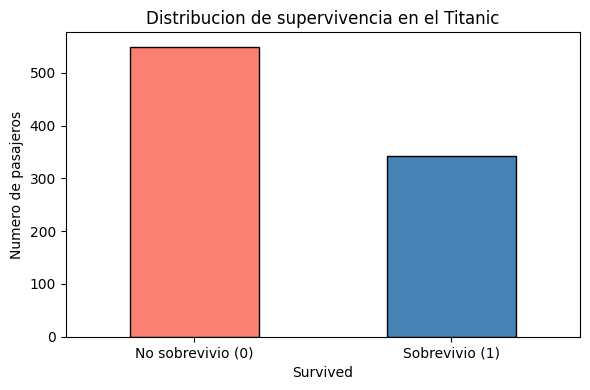

In [6]:
# Contamos cuantos pasajeros sobrevivieron y cuantos no
print("Distribucion de la variable objetivo (Survived):")
print(df['Survived'].value_counts())
print(f"\nPorcentaje de supervivencia: {df['Survived'].mean()*100:.1f}%")

# Visualizamos la distribucion
plt.figure(figsize=(6, 4))
df['Survived'].value_counts().plot(kind='bar', color=['salmon', 'steelblue'], edgecolor='black')
plt.xticks([0, 1], ['No sobrevivio (0)', 'Sobrevivio (1)'], rotation=0)
plt.ylabel('Numero de pasajeros')
plt.title('Distribucion de supervivencia en el Titanic')
plt.tight_layout()
plt.show()

## 4. Preparacion de los datos

Los modelos de machine learning no pueden trabajar directamente con texto ni con valores nulos. Necesitamos preparar los datos antes de entrenar.

En esta sesion simplificaremos al maximo esta etapa para centrarnos en el flujo completo. Seguiremos estos pasos:

1. Seleccionar unicamente las columnas numericas que tienen sentido para la prediccion
2. Rellenar los valores nulos con la media de cada columna

> **Nota:** Esta preparacion es muy basica. En la Sesion 2 veremos como hacerlo correctamente usando tecnicas de limpieza, codificacion categorica (one-hot encoding) y normalizacion.

In [7]:
# Seleccionamos las columnas que usaremos como variables de entrada (features)
# Por ahora usamos solo columnas numericas que no tienen demasiados nulos
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']

# X contiene las variables de entrada (lo que usamos para predecir)
X = df[features].copy()

# y contiene la variable objetivo (lo que queremos predecir)
y = df['Survived']

print("Variables de entrada (X):")
print(X.head())
print(f"\nForma de X: {X.shape}  (filas, columnas)")
print(f"Forma de y: {y.shape}  (filas,)")

Variables de entrada (X):
   Pclass   Age  SibSp  Parch     Fare
0       3  22.0      1      0   7.2500
1       1  38.0      1      0  71.2833
2       3  26.0      0      0   7.9250
3       1  35.0      1      0  53.1000
4       3  35.0      0      0   8.0500

Forma de X: (891, 5)  (filas, columnas)
Forma de y: (891,)  (filas,)


In [8]:
# Comprobamos si hay valores nulos en las columnas que vamos a usar
print("Valores nulos por columna:")
print(X.isnull().sum())

Valores nulos por columna:
Pclass      0
Age       177
SibSp       0
Parch       0
Fare        0
dtype: int64


In [9]:
# Rellenamos los valores nulos con la media de cada columna
# fillna() reemplaza los NaN por el valor que le indiquemos
# mean() calcula la media de cada columna
X = X.fillna(X.mean())

print("Valores nulos despues del relleno:")
print(X.isnull().sum())
print("\nYa no hay valores nulos.")

Valores nulos despues del relleno:
Pclass    0
Age       0
SibSp     0
Parch     0
Fare      0
dtype: int64

Ya no hay valores nulos.


## 5. Division en conjunto de entrenamiento y conjunto de prueba

Este es uno de los conceptos mas importantes del machine learning. Necesitamos:

- **Conjunto de entrenamiento (train set):** los datos que el modelo usa para aprender. El modelo ajusta sus parametros internos usando estos ejemplos.
- **Conjunto de prueba (test set):** datos que el modelo NO ha visto durante el entrenamiento. Los usamos para evaluar si el modelo generaliza bien a nuevos datos.

Si evaluaramos el modelo sobre los mismos datos con los que entrenamos, podriamos pensar que funciona muy bien cuando en realidad simplemente ha "memorizado" los datos. A esto se le llama **overfitting** (sobreajuste).

La funcion `train_test_split` de scikit-learn divide los datos automaticamente. El parametro `test_size=0.2` indica que el 20% de los datos se reserva para prueba y el 80% para entrenamiento. El parametro `random_state` fija una semilla aleatoria para que los resultados sean reproducibles y no cambien cada vez que reejecutamos el código.

In [10]:
# Dividimos los datos: 80% para entrenar, 20% para evaluar
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # El 20% de los datos sera para prueba
    random_state=42,    # Semilla para reproducibilidad (vale cualquier número)
    stratify=y          # Mantiene la misma proporcion de clases en train y test
)

print(f"Tamano del conjunto de entrenamiento: {X_train.shape[0]} pasajeros")
print(f"Tamano del conjunto de prueba:        {X_test.shape[0]} pasajeros")
print(f"\nPorcentaje de supervivencia en train: {y_train.mean()*100:.1f}%")
print(f"Porcentaje de supervivencia en test:  {y_test.mean()*100:.1f}%")

Tamano del conjunto de entrenamiento: 712 pasajeros
Tamano del conjunto de prueba:        179 pasajeros

Porcentaje de supervivencia en train: 38.3%
Porcentaje de supervivencia en test:  38.5%


Gracias al parametro `stratify=y`, la proporcion de supervivientes es muy similar en ambos conjuntos.

## 6. Entrenamiento del clasificador

Vamos a entrenar un **MLPClassifier** (Multi-Layer Perceptron Classifier), que es una red neuronal artificial de tipo feedforward.

Una red neuronal esta formada por capas de neuronas artificiales:
- **Capa de entrada:** recibe las variables de entrada (nuestras 5 columnas)
- **Capas ocultas:** procesan la informacion y aprenden representaciones intermedias
- **Capa de salida:** produce la prediccion (sobrevive o no)

El parametro `hidden_layer_sizes=(100, 50)` indica que la red tiene dos capas ocultas: la primera con 100 neuronas y la segunda con 50. El parametro `max_iter` controla cuantas veces el algoritmo puede recorrer los datos de entrenamiento.

En scikit-learn, todos los modelos siguen la misma interfaz:
1. Se crea el modelo con sus parametros
2. Se llama a `fit(X_train, y_train)` para entrenar
3. Se llama a `predict(X_test)` para hacer predicciones

In [11]:
# Creamos el clasificador
# hidden_layer_sizes: tupla con el numero de neuronas en cada capa oculta
# max_iter: numero maximo de iteraciones del algoritmo de entrenamiento
# random_state: semilla para reproducibilidad
modelo = MLPClassifier(
    hidden_layer_sizes=(100, 50),
    max_iter=500,
    random_state=42
)

# Entrenamos el modelo con los datos de entrenamiento
# fit() ajusta los pesos de la red neuronal
modelo.fit(X_train, y_train)

print("Entrenamiento completado.")

Entrenamiento completado.


> ### ¿Enhorabuena! Has entrenado tu primer modelo de ML

## 7. Evaluacion del modelo

### 7.1 Exactitud (Accuracy)

La metrica mas intuitiva es la **exactitud (accuracy)**: el porcentaje de predicciones correctas sobre el total.

In [12]:
# Hacemos predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

# Calculamos la exactitud
exactitud = accuracy_score(y_test, y_pred)
print(f"Exactitud en el conjunto de prueba: {exactitud*100:.2f}%")
print(f"\nEs decir, el modelo acierta {exactitud*100:.1f} de cada 100 predicciones.")

Exactitud en el conjunto de prueba: 65.92%

Es decir, el modelo acierta 65.9 de cada 100 predicciones.


> ### ¿Cuál sería el % de acierto si simplemente hicieramos la predicción aleatoriamente?
>
> ### ¿Qué habría pasado de no haber utilizado la estratificación al dividir entre conjuntos de entrenamiento y prueba?
>
> Escribe aquí tus respuestas

### 7.2 La matriz de confusion

La exactitud por si sola no cuenta toda la historia. La **matriz de confusion** nos da mucha mas informacion sobre los errores que comete el modelo.

Para un clasificador binario, la matriz de confusion es una tabla 2x2 que muestra:

| | Prediccion: No sobrevivio (0) | Prediccion: Sobrevivio (1) |
|---|---|---|
| **Real: No sobrevivio (0)** | Verdadero Negativo (TN) | Falso Positivo (FP) |
| **Real: Sobrevivio (1)** | Falso Negativo (FN) | Verdadero Positivo (TP) |

Significado de cada celda:
- **Verdadero Positivo (TP):** el pasajero sobrevivio y el modelo predijo que sobreviviria. Acierto.
- **Verdadero Negativo (TN):** el pasajero no sobrevivio y el modelo predijo que no sobreviviria. Acierto.
- **Falso Positivo (FP):** el pasajero no sobrevivio pero el modelo predijo que sobreviviria. Error de tipo I.
- **Falso Negativo (FN):** el pasajero sobrevivio pero el modelo predijo que no sobreviviria. Error de tipo II.

Matriz de confusion (valores absolutos):
[[85 25]
 [36 33]]

Filas = valor real, Columnas = valor predicho
Orden: [No sobrevivio, Sobrevivio]


<Figure size 600x500 with 0 Axes>

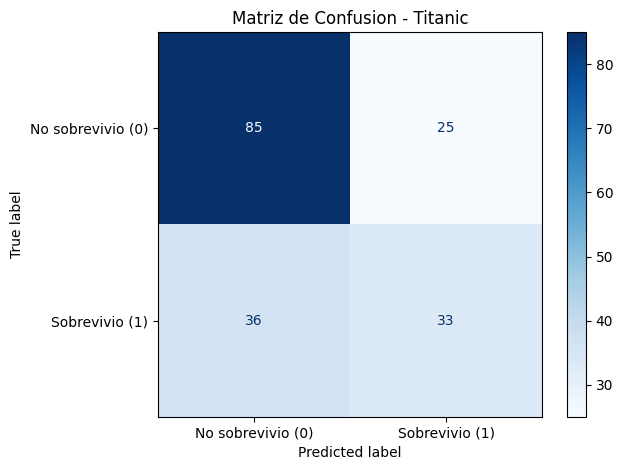

In [ ]:
# Calculamos la matriz de confusion
cm = confusion_matrix(y_test, y_pred)

print("Matriz de confusion (valores absolutos):")
print(cm)
print("\nFilas = valor real, Columnas = valor predicho")
print("Orden: [No sobrevivio, Sobrevivio]")
plt.figure(figsize=(6, 5))


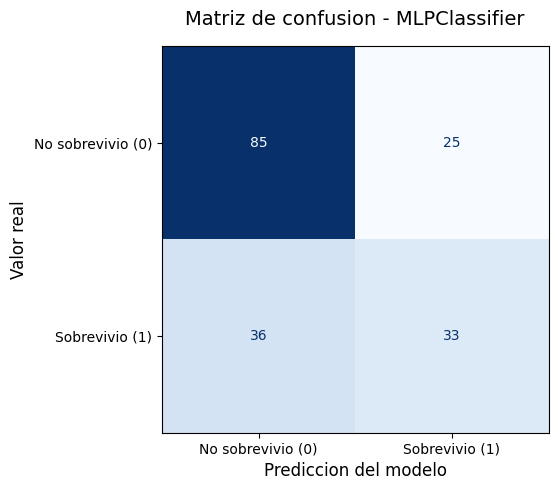


Verdaderos Negativos (TN): 85  -- No sobrevivio y modelo predijo que no
Falsos Positivos     (FP): 25  -- No sobrevivio pero modelo predijo que si
Falsos Negativos     (FN): 36  -- Sobrevivio pero modelo predijo que no
Verdaderos Positivos (TP): 33  -- Sobrevivio y modelo predijo que si


In [ ]:
# Visualizamos la matriz de confusion de forma mas clara
fig, ax = plt.subplots(figsize=(7, 5))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No sobrevivio (0)', 'Sobrevivio (1)']
)
disp.plot(ax=ax, cmap='Blues', colorbar=False)

ax.set_title('Matriz de confusion - MLPClassifier', fontsize=14, pad=15)
ax.set_xlabel('Prediccion del modelo', fontsize=12)
ax.set_ylabel('Valor real', fontsize=12)
plt.tight_layout()
plt.show()

# Extraemos los valores individuales
tn, fp, fn, tp = cm.ravel()
print(f"\nVerdaderos Negativos (TN): {tn}  -- No sobrevivio y modelo predijo que no")
print(f"Falsos Positivos     (FP): {fp}  -- No sobrevivio pero modelo predijo que si")
print(f"Falsos Negativos     (FN): {fn}  -- Sobrevivio pero modelo predijo que no")
print(f"Verdaderos Positivos (TP): {tp}  -- Sobrevivio y modelo predijo que si")

### 7.3 Metricas derivadas de la matriz de confusion

A partir de los cuatro valores de la matriz de confusion (TP, TN, FP, FN) se calculan varias metricas que miden diferentes aspectos del rendimiento del clasificador:

**Precision:** de todos los ejemplos que el modelo clasifico como positivos (sobrevivio), cuantos realmente lo eran.

$$\text{Precision} = \frac{TP}{TP + FP}$$

**Recall (Sensibilidad):** de todos los ejemplos que realmente eran positivos (sobrevivio), cuantos identifico correctamente el modelo.

$$\text{Recall} = \frac{TP}{TP + FN}$$

**F1-Score:** media armonica entre precision y recall. Es util cuando queremos un balance entre ambas.

$$\text{F1} = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

In [16]:
# El classification_report muestra todas las metricas de una vez
# Para cada clase y tambien un promedio global
print("Informe de clasificacion completo:")
print("="*60)
print(classification_report(y_test, y_pred, target_names=['No sobrevivio', 'Sobrevivio']))

Informe de clasificacion completo:
               precision    recall  f1-score   support

No sobrevivio       0.70      0.77      0.74       110
   Sobrevivio       0.57      0.48      0.52        69

     accuracy                           0.66       179
    macro avg       0.64      0.63      0.63       179
 weighted avg       0.65      0.66      0.65       179



In [17]:
# Calculamos manualmente las metricas para la clase positiva (sobrevivio = 1)
tn, fp, fn, tp = cm.ravel()

precision = tp / (tp + fp)
recall    = tp / (tp + fn)
f1        = 2 * (precision * recall) / (precision + recall)
accuracy  = (tp + tn) / (tp + tn + fp + fn)

print("Metricas para la clase positiva (Sobrevivio = 1):")
print(f"  Exactitud  (Accuracy):  {accuracy:.4f}  ({accuracy*100:.1f}%)")
print(f"  Precision:              {precision:.4f}  ({precision*100:.1f}%)")
print(f"  Recall:                 {recall:.4f}  ({recall*100:.1f}%)")
print(f"  F1-Score:               {f1:.4f}")

Metricas para la clase positiva (Sobrevivio = 1):
  Exactitud  (Accuracy):  0.6592  (65.9%)
  Precision:              0.5690  (56.9%)
  Recall:                 0.4783  (47.8%)
  F1-Score:               0.5197



> ### Para el problema del Titanic, ¿cual crees que es mas grave: un falso positivo o un falso negativo? 
> ### ¿Y si este fuera un modelo de diagnostico de cancer? ¿Y un sistema de inversión de acciones bursátiles? ¿Qué importa más, la precisión o el recall en estos dominios?

## 8. Interpretacion de los resultados

Vamos a visualizar de forma mas intuitiva que tipo de errores esta cometiendo el modelo.

In [18]:
# Creamos un DataFrame con los resultados para analizarlos mejor
resultados = X_test.copy()
resultados['Real'] = y_test.values
resultados['Prediccion'] = y_pred
resultados['Correcto'] = (resultados['Real'] == resultados['Prediccion'])

print(f"Total de predicciones: {len(resultados)}")
print(f"  Predicciones correctas:   {resultados['Correcto'].sum()} ({resultados['Correcto'].mean()*100:.1f}%)")
print(f"  Predicciones incorrectas: {(~resultados['Correcto']).sum()} ({(~resultados['Correcto']).mean()*100:.1f}%)")

Total de predicciones: 179
  Predicciones correctas:   118 (65.9%)
  Predicciones incorrectas: 61 (34.1%)


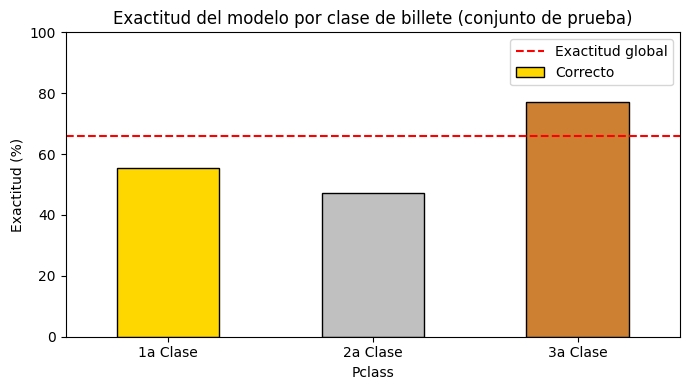

In [19]:
# Visualizamos la precision por clase del billete
# Queremos ver si el modelo funciona mejor para alguna clase
resultados_train = X_train.copy()
resultados_train['Real'] = y_train.values
resultados_train['Prediccion'] = modelo.predict(X_train)
resultados_train['Correcto'] = (resultados_train['Real'] == resultados_train['Prediccion'])

# Agrupamos por clase de billete y calculamos la precision
precision_por_clase = resultados.groupby('Pclass')['Correcto'].mean() * 100

plt.figure(figsize=(7, 4))
precision_por_clase.plot(kind='bar', color=['gold', 'silver', '#cd7f32'], edgecolor='black')
plt.xticks([0, 1, 2], ['1a Clase', '2a Clase', '3a Clase'], rotation=0)
plt.ylabel('Exactitud (%)')
plt.title('Exactitud del modelo por clase de billete (conjunto de prueba)')
plt.ylim(0, 100)
plt.axhline(y=exactitud*100, color='red', linestyle='--', label='Exactitud global')
plt.legend()
plt.tight_layout()
plt.show()

## 9. El pipeline completo: resumen

Hemos completado el flujo completo de un proyecto de machine learning. Vamos a ver el codigo minimo necesario para reproducir todo lo que hemos hecho.

In [27]:
# RESUMEN: Pipeline completo en pocas lineas
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Cargar datos
df = pd.read_csv("https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv")

# 2. Preparar datos
features = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
X = df[features].fillna(df[features].mean())
y = df['Survived']

# 3. Dividir en train y test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Entrenar el modelo
modelo = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
modelo.fit(X_train, y_train)

# 5. Evaluar el modelo
y_pred = modelo.predict(X_test)
print(f"Exactitud: {accuracy_score(y_test, y_pred)*100:.2f}%")
print(classification_report(y_test, y_pred, target_names=['No sobrevivio', 'Sobrevivio']))

Exactitud: 65.92%
               precision    recall  f1-score   support

No sobrevivio       0.70      0.77      0.74       110
   Sobrevivio       0.57      0.48      0.52        69

     accuracy                           0.66       179
    macro avg       0.64      0.63      0.63       179
 weighted avg       0.65      0.66      0.65       179



## 10. Ejercicios propuestos

Intenta resolver los siguientes ejercicios para afianzar lo aprendido:


> ### **Ejercicio 1.** Modifica la arquitectura de la red neuronal cambiando el parametro `hidden_layer_sizes`. Por ejemplo, prueba con `(50,)`, `(200, 100, 50)` o `(10,)`. Como cambian los resultados?


In [31]:


arquitecturas = {
    '(10,)':          (10,),
    '(50,)':          (50,),
    '(100, 50)':      (100, 50),   
    '(200, 100, 50)': (200, 100, 50),
}

resultados_ej1 = {}
for nombre, arch in arquitecturas.items():
    
    m = MLPClassifier(hidden_layer_sizes=arch, max_iter=500, random_state=42)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    resultados_ej1[nombre] = acc
    print(f"  {nombre:20s}  →  Exactitud: {acc*100:.2f}%")

  (10,)                 →  Exactitud: 68.16%
  (50,)                 →  Exactitud: 67.04%
  (100, 50)             →  Exactitud: 65.92%
  (200, 100, 50)        →  Exactitud: 69.27%


> ### **Ejercicio 2.** Cambia el parametro `test_size` a `0.3` (30% para prueba). ¿Aumenta o disminuye la exactitud? A que crees que se debe?


In [33]:
print("\n── Ejercicio 2: test_size 0.2 vs 0.3 ──")
for ts in [0.2, 0.3]:
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=ts, random_state=42, stratify=y)
    m = MLPClassifier(hidden_layer_sizes=(100,50), max_iter=500, random_state=42)
    m.fit(X_train, y_train)
    acc = accuracy_score(y_test, m.predict(X_test))
    print(f"  test_size={ts}  →  train={len(X_train)}, test={len(X_test)}, exactitud={acc*100:.2f}%")


── Ejercicio 2: test_size 0.2 vs 0.3 ──
  test_size=0.2  →  train=712, test=179, exactitud=65.92%
  test_size=0.3  →  train=623, test=268, exactitud=65.30%



> ### **Ejercicio 3.** Ahora que ya sabes lo que hace cada columna, intenta anadir la columna `Sex` al conjunto de variables. Pista: tendras que convertir los valores de texto ('male', 'female') a numeros. Puedes hacerlo con `df['Sex'].map({'male': 0, 'female': 1})`. ¿Mejora la exactitud?

In [36]:
# 1. Modelo BASE (sin Sex) — se calcula aquí explícitamente
features_base = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
X_base = df[features_base].copy().fillna(df[features_base].mean())
y = df['Survived']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y)

modelo_base = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
modelo_base.fit(X_train_b, y_train_b)
y_pred_base = modelo_base.predict(X_test_b)
acc_base = accuracy_score(y_test_b, y_pred_base)   # ← ahora sí está definido

# 2. Modelo CON Sex
df_sex = df.copy()
df_sex['Sex_num'] = df_sex['Sex'].map({'male': 0, 'female': 1})
features_sex = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_num']
X_sex = df_sex[features_sex].copy().fillna(df_sex[features_sex].mean())

Xtr_s, Xte_s, ytr_s, yte_s = train_test_split(
    X_sex, y, test_size=0.2, random_state=42, stratify=y)

m_sex = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
m_sex.fit(Xtr_s, ytr_s)
ypred_sex = m_sex.predict(Xte_s)
acc_sex = accuracy_score(yte_s, ypred_sex)

print("── Ejercicio 3: Con y sin la variable Sex ──")
print(f"  Sin Sex:  {acc_base*100:.2f}%")
print(f"  Con Sex:  {acc_sex*100:.2f}%  ({(acc_sex-acc_base)*100:+.2f}pp)")
print()
print(classification_report(yte_s, ypred_sex, target_names=['No sobrevivio', 'Sobrevivio']))

── Ejercicio 3: Con y sin la variable Sex ──
  Sin Sex:  65.92%
  Con Sex:  76.54%  (+10.61pp)

               precision    recall  f1-score   support

No sobrevivio       0.75      0.92      0.83       110
   Sobrevivio       0.80      0.52      0.63        69

     accuracy                           0.77       179
    macro avg       0.78      0.72      0.73       179
 weighted avg       0.77      0.77      0.75       179



> ###  **Ejercicio 4.** Observa el classification report. La precision y el recall son distintos para cada clase. Que clase tiene mayor recall? Que significa eso en terminos de los errores que comete el modelo?


In [ ]:
#Reproducir el pipeline base completo
features_base = ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
X_base = df[features_base].copy().fillna(df[features_base].mean())
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42, stratify=y)

modelo = MLPClassifier(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
modelo.fit(X_train, y_train)
y_pred = modelo.predict(X_test)    # ← ahora sí definido

# Calcular la matriz de confusión
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()       # ← ahora sí definido

# Métricas derivadas para cada clase
precision_surv = tp / (tp + fp)
recall_surv    = tp / (tp + fn)
f1_surv        = 2 * precision_surv * recall_surv / (precision_surv + recall_surv)

precision_no   = tn / (tn + fn)
recall_no      = tn / (tn + fp)
f1_no          = 2 * precision_no * recall_no / (precision_no + recall_no)

# Classification report completo
print("── Ejercicio 4: Classification Report ──")
print(classification_report(y_test, y_pred, target_names=['No sobrevivio', 'Sobrevivio']))

print("── Análisis del Recall por clase ──")
print(f"  Recall 'No sobrevivio':  {recall_no:.2f}  → identifica el {recall_no*100:.1f}% de los que NO sobrevivieron")
print(f"  Recall 'Sobrevivio':     {recall_surv:.2f}  → identifica el {recall_surv*100:.1f}% de los que SÍ sobrevivieron")
print()
print(f"  ➜ Mayor recall: 'No sobrevivio' ({recall_no:.2f})")
print(f"    El modelo casi siempre predice que el pasajero NO sobrevive,")
print(f"    por eso acierta mucho en esa clase pero comete muchos")
print(f"    Falsos Negativos (FN={fn}): supervivientes que no detecta.")

── Ejercicio 4: Classification Report ──
               precision    recall  f1-score   support

No sobrevivio       0.70      0.77      0.74       110
   Sobrevivio       0.57      0.48      0.52        69

     accuracy                           0.66       179
    macro avg       0.64      0.63      0.63       179
 weighted avg       0.65      0.66      0.65       179

── Análisis del Recall por clase ──
  Recall 'No sobrevivio':  0.77  → identifica el 77.3% de los que NO sobrevivieron
  Recall 'Sobrevivio':     0.48  → identifica el 47.8% de los que SÍ sobrevivieron

  ➜ Mayor recall: 'No sobrevivio' (0.77)
    El modelo casi siempre predice que el pasajero NO sobrevive,
    por eso acierta mucho en esa clase pero comete muchos
    Falsos Negativos (FN=36): supervivientes que no detecta.
